# **6주차 강화학습 실습**

안녕하세요.

Tobig's 24기 서민정, 정서윤입니다.

본 실습은 3x4 그리드 월드(GridWorld) 환경에서 에이전트가 함정을 피하고 목표 지점에 도달하는 최적의 경로를 학습하는 과정을 다룹니다.

환경의 완벽한 정보를 안다고 가정하는 동적 계획법(DP)부터, 경험을 통해 학습하는 몬테카를로(MC)와 시간차 학습(TD) 알고리즘까지 순차적으로 구현해봅니다. 이를 통해 각 강화학습 알고리즘의 작동 원리를 깊이 이해하고, 실질적인 차이점을 비교 분석해보겠습니다.

# **3x4 그리드 월드**

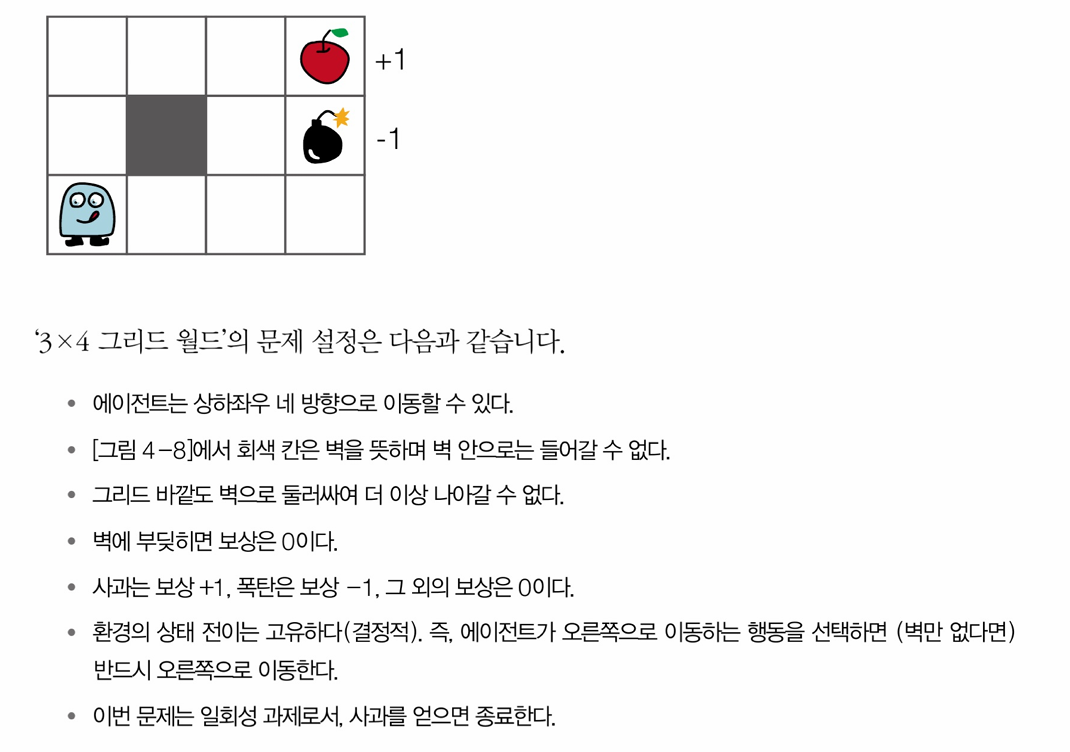

# **동적 프로그래밍(Dynamic Programming)**

동적 계획법은 환경의 전이 확률과 보상 함수를 모두 알고 있다는 가정 하에 동작합니다. 가치 반복(Value Iteration)은 벨만 최적 방정식을 업데이트 규칙으로 사용하여, 상태 가치 함수가 수렴할 때까지 반복 계산하여 최적 가치 함수와 최적 정책을 찾습니다.

**SETUP**

In [2]:
# install gridworld from pip
!pip install dezerogym

**1. 환경 초기화 및 무작위 가치 함수 시각화**

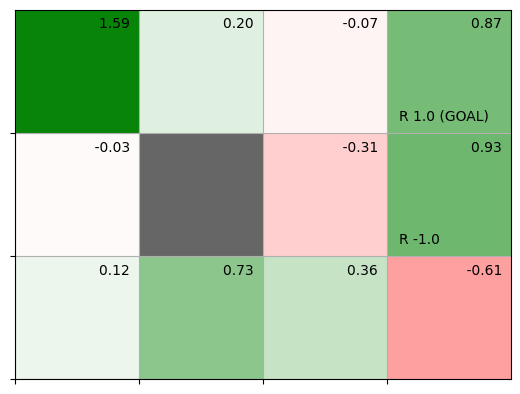

In [3]:
import numpy as np
from dezerogym.gridworld import GridWorld

env = GridWorld()
V = {}

for state in env.states():
    V[state] = np.random.randn()
env.render_v(V)

**2. 정책 평가 (Policy Evaluation)**

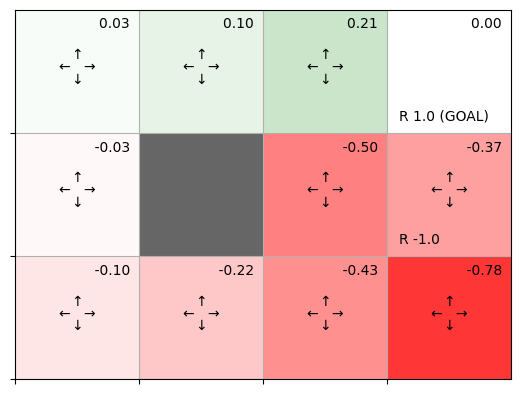

In [4]:
from collections import defaultdict
from dezerogym.gridworld import GridWorld


def eval_onestep(pi, V, env, gamma=0.9):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_probs = pi[state]
        new_V = 0
        for action, action_prob in action_probs.items():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            new_V += action_prob * (r + gamma * V[next_state])
        V[state] = new_V
    return V


def policy_eval(pi, V, env, gamma, threshold=0.001):
    while True:
        old_V = V.copy()
        V = eval_onestep(pi, V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


env = GridWorld()
gamma = 0.9

pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
V = defaultdict(lambda: 0)

V = policy_eval(pi, V, env, gamma)
env.render_v(V, pi)

**3. 정책 반복 (Policy Iteration)**

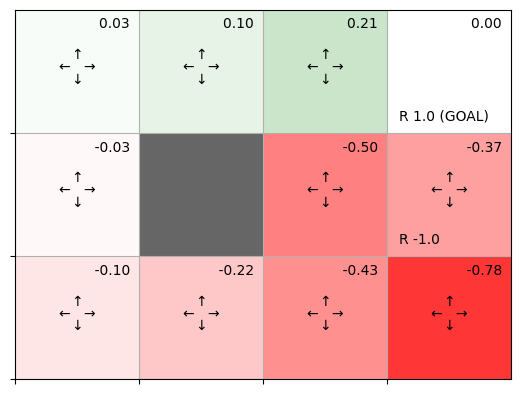

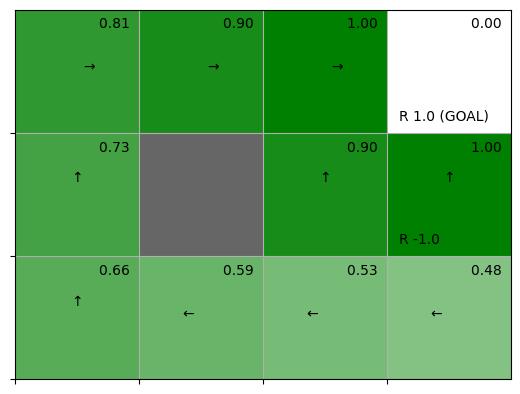

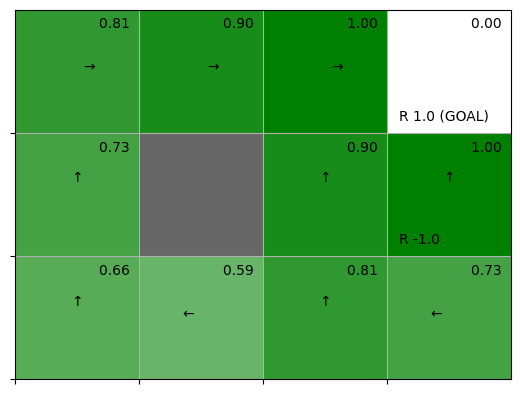

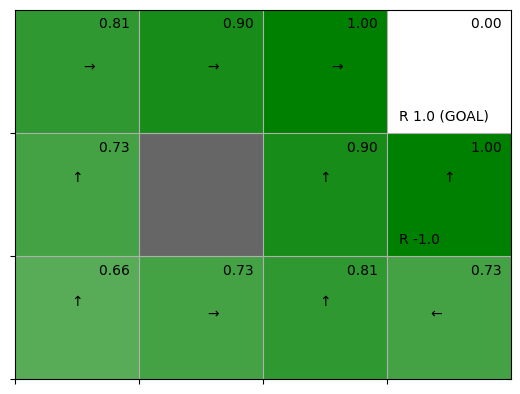

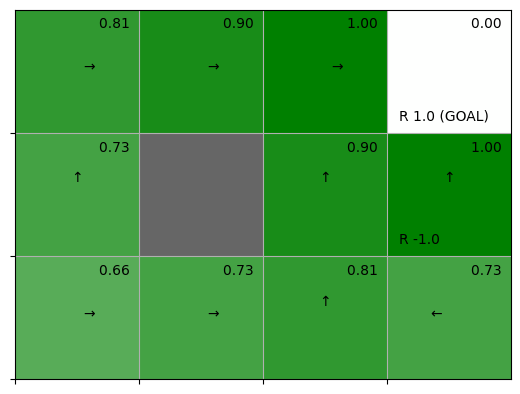

In [5]:
def argmax(d):
    """d (dict)"""
    max_value = max(d.values())
    max_key = -1
    for key, value in d.items():
        if value == max_value:
            max_key = key
    return max_key


def greedy_policy(V, env, gamma):
    pi = {}

    for state in env.states():
        action_values = {}

        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values[action] = value

        max_action = argmax(action_values)
        action_probs = {0: 0, 1: 0, 2: 0, 3: 0}
        action_probs[max_action] = 1.0
        pi[state] = action_probs
    return pi


def policy_iter(env, gamma, threshold=0.001, is_render=True):
    pi = defaultdict(lambda: {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25})
    V = defaultdict(lambda: 0)

    while True:
        V = policy_eval(pi, V, env, gamma, threshold)
        new_pi = greedy_policy(V, env, gamma)

        if is_render:
            env.render_v(V, pi)

        if new_pi == pi:
            break
        pi = new_pi

    return pi


env = GridWorld()
gamma = 0.9
pi = policy_iter(env, gamma)


**4. 가치 반복 (Value Iteration)**

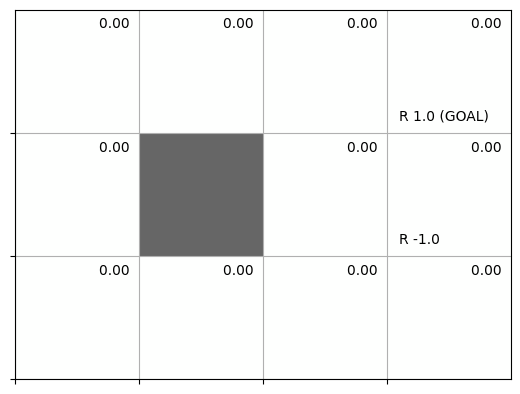

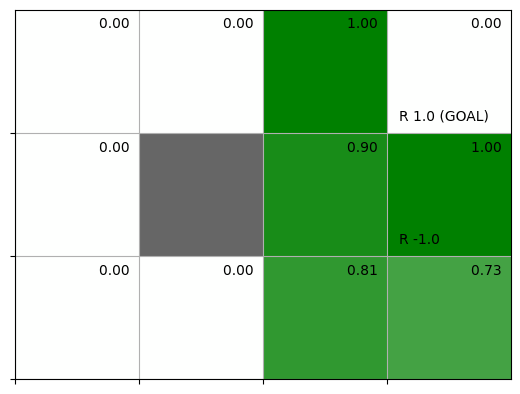

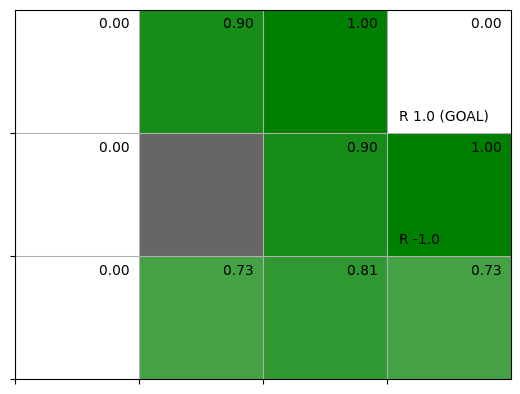

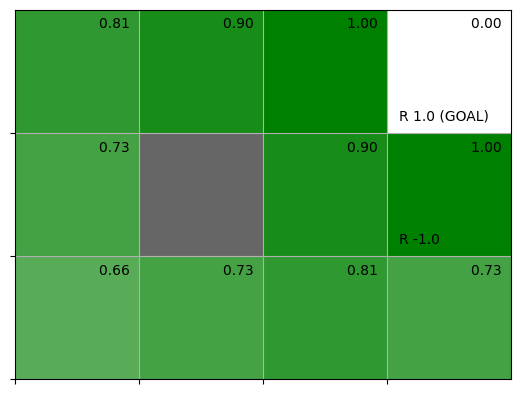

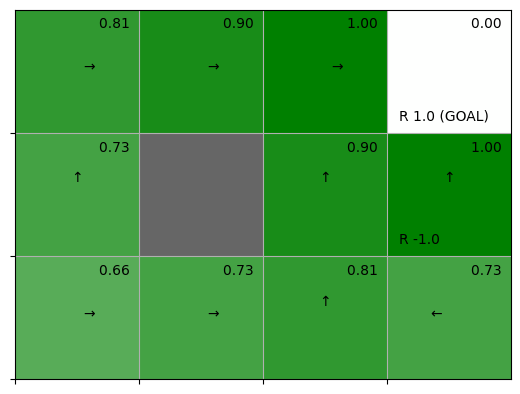

In [6]:
def value_iter_onestep(V, env, gamma):
    for state in env.states():
        if state == env.goal_state:
            V[state] = 0
            continue

        action_values = []
        for action in env.actions():
            next_state = env.next_state(state, action)
            r = env.reward(state, action, next_state)
            value = r + gamma * V[next_state]
            action_values.append(value)

        V[state] = max(action_values)
    return V


def value_iter(V, env, gamma, threshold=0.001, is_render=True):
    while True:
        if is_render:
            env.render_v(V)

        old_V = V.copy()
        V = value_iter_onestep(V, env, gamma)

        delta = 0
        for state in V.keys():
            t = abs(V[state] - old_V[state])
            if delta < t:
                delta = t

        if delta < threshold:
            break
    return V


V = defaultdict(lambda: 0)
env = GridWorld()
gamma = 0.9

V = value_iter(V, env, gamma)

pi = greedy_policy(V, env, gamma)
env.render_v(V, pi)

# **몬테카를로법(Monte Carlo Method)**

몬테카를로 방법은 환경의 모델을 모를 때, 에이전트가 직접 환경과 상호작용하며 얻은 에피소드(경험)를 바탕으로 학습합니다. 에피소드가 끝날 때까지 기다렸다가 실제 얻은 반환값을 사용하여 Q-함수를 업데이트합니다. 여기서 구현하는 비활성 정책(Off-policy) MC는 탐험을 위한 행동 정책(Behavior Policy)과 최적화하려는 목표 정책(Target Policy)을 분리하고 중요도 샘플링을 적용합니다.

**SETUP**

In [7]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld

**1. 무작위 에이전트를 이용한 MC 정책 평가**

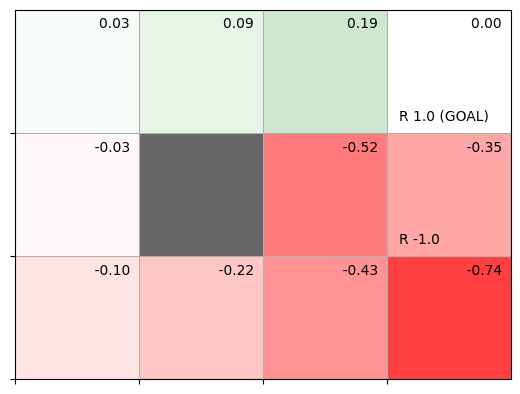

In [8]:
class RandomAgent:
    def __init__(self):
        self.gamma = 0.9
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)
        self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def eval(self):
        G = 0
        for data in reversed(self.memory):  # 역방향으로(reserved) 따라가기
            state, action, reward = data
            G = self.gamma * G + reward
            self.cnts[state] += 1
            self.V[state] += (G - self.V[state]) / self.cnts[state]


env = GridWorld()
agent = RandomAgent()

episodes = 1000
for episode in range(episodes):  # 에피소드 1000번 수행
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)             # 행동 선택
        next_state, reward, done = env.step(action)  # 행동 수행

        agent.add(state, action, reward)  # (상태, 행동, 보상) 저장
        if done:   # 목표에 도달 시
            agent.eval()  # 몬테카를로법으로 가치 함수 갱신
            break         # 다음 에피소드 시작

        state = next_state

# 모든 에피소드 종료

# 가치 함수 시각화
env.render_v(agent.V)

**[공통 유틸리티] 엡실론-탐욕(epsilon-greedy) 확률 계산 함수**

In [9]:
def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = np.argmax(qs)

    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**2. 활성 정책 MC 제어 (On-Policy MC Control)**

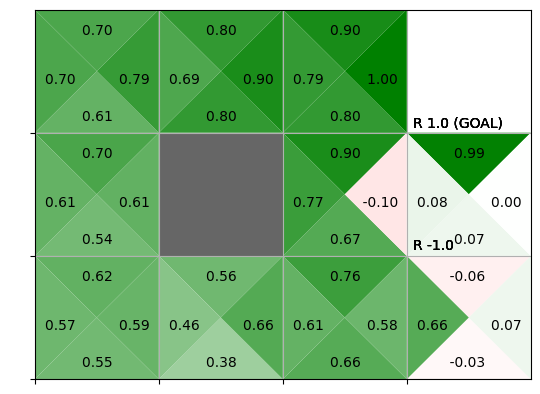

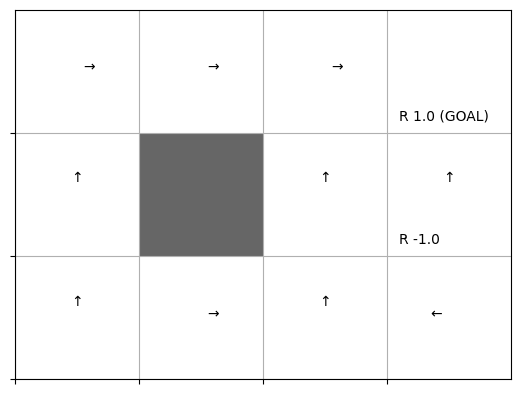

In [10]:
class McAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1  # (첫 번째 개선) ε-탐욕 정책의 ε
        self.alpha = 0.1    # (두 번째 개선) Q 함수 갱신 시의 고정값 α
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        # self.cnts = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        for data in reversed(self.memory):
            state, action, reward = data
            G = self.gamma * G + reward
            key = (state, action)
            # self.cnts[key] += 1
            # self.Q[key] += (G - self.Q[key]) / self.cnts[key]
            self.Q[key] += (G - self.Q[key]) * self.alpha
            self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 MC 제어 (Off-Policy MC Control)**

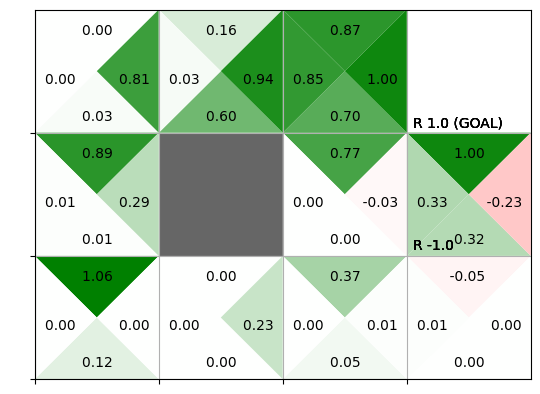

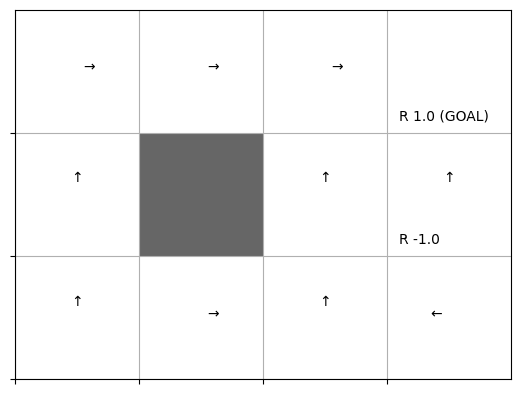

In [11]:
class McOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.epsilon = 0.1
        self.alpha = 0.2
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = []

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def add(self, state, action, reward):
        data = (state, action, reward)
        self.memory.append(data)

    def reset(self):
        self.memory.clear()

    def update(self):
        G = 0
        rho = 1

        for data in reversed(self.memory):
            state, action, reward = data
            key = (state, action)

            G = self.gamma * rho * G + reward
            self.Q[key] += (G - self.Q[key]) * self.alpha
            rho *= self.pi[state][action] / self.b[state][action]

            self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
            self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = McOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.add(state, action, reward)
        if done:
            agent.update()
            break

        state = next_state

env.render_q(agent.Q)

# **TD법(Temporal Difference Methods)**

시간차(TD) 학습은 MC와 마찬가지로 모델 없이 학습하지만, 에피소드가 끝날 때까지 기다리지 않고 매 타임스텝마다 학습합니다. Q-Learning은 TD의 대표적인 비활성 정책 제어 알고리즘으로, 다음 상태에서 가능한 가장 큰 Q-값을 다음 타겟으로 사용하여 현재 상태의 Q-값을 실시간으로 업데이트합니다.

**[공통 유틸리티 함수]**

In [12]:
# utility functions (common functions)
def argmax(xs):
    idxes = [i for i, x in enumerate(xs) if x == max(xs)]
    if len(idxes) == 1:
        return idxes[0]
    elif len(idxes) == 0:
        return np.random.choice(len(xs))
    selected = np.random.choice(idxes)
    return selected

def greedy_probs(Q, state, epsilon=0, action_size=4):
    qs = [Q[(state, action)] for action in range(action_size)]
    max_action = argmax(qs)  # OR np.argmax(qs)
    base_prob = epsilon / action_size
    action_probs = {action: base_prob for action in range(action_size)}  #{0: ε/4, 1: ε/4, 2: ε/4, 3: ε/4}
    action_probs[max_action] += (1 - epsilon)
    return action_probs

**1. TD 정책 평가 (TD Evaluation)**

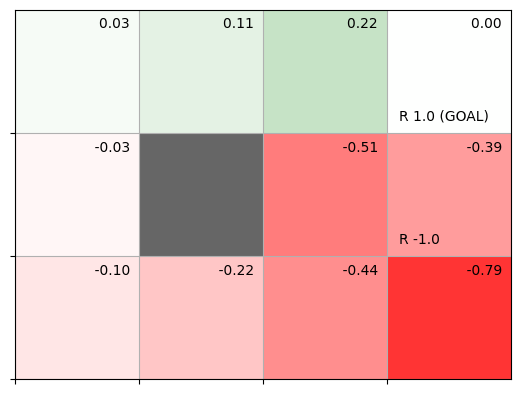

In [13]:
from collections import defaultdict
import numpy as np
from dezerogym.gridworld import GridWorld


class TdAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.01
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.V = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def eval(self, state, reward, next_state, done):
        next_V = 0 if done else self.V[next_state]
        target = reward + self.gamma * next_V
        self.V[state] += (target - self.V[state]) * self.alpha


env = GridWorld()
agent = TdAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.eval(state, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_v(agent.V)

**2. SARSA (활성 정책 TD 제어, On-Policy TD Control)**

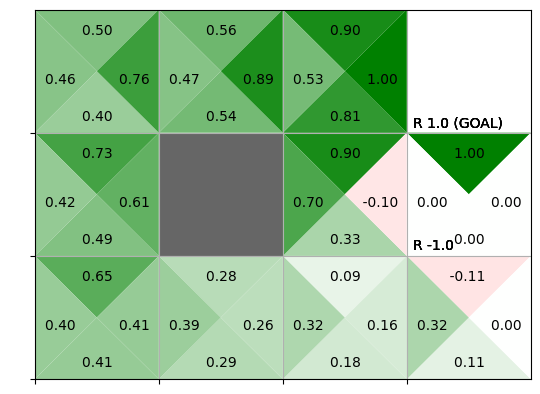

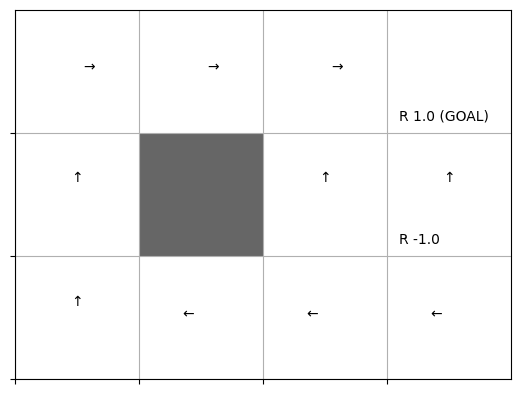

In [14]:
from collections import deque


class SarsaAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.pi[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]
        next_q = 0 if done else self.Q[next_state, next_action]

        target = reward + self.gamma * next_q
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha
        self.pi[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**3. 비활성 정책 SARSA (Off-Policy SARSA)**

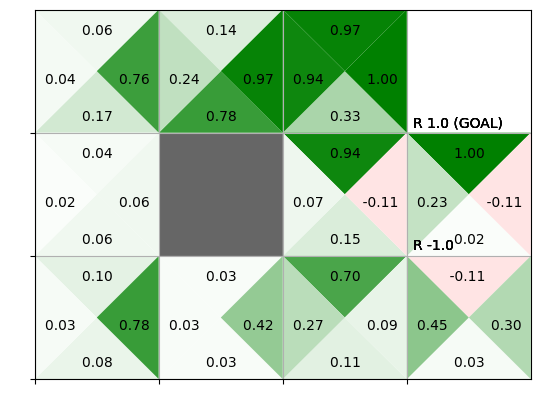

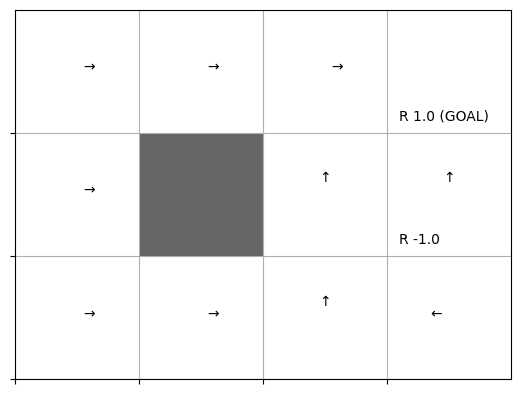

In [15]:
class SarsaOffPolicyAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)
        self.memory = deque(maxlen=2)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def reset(self):
        self.memory.clear()

    def update(self, state, action, reward, done):
        self.memory.append((state, action, reward, done))
        if len(self.memory) < 2:
            return

        state, action, reward, done = self.memory[0]
        next_state, next_action, _, _ = self.memory[1]

        if done:
            next_q = 0
            rho = 1
        else:
            next_q = self.Q[next_state, next_action]
            rho = self.pi[next_state][next_action] / self.b[next_state][next_action]

        target = rho * (reward + self.gamma * next_q)
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, 0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = SarsaOffPolicyAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()
    agent.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, done)

        if done:
            agent.update(next_state, None, None, None)
            break
        state = next_state

env.render_q(agent.Q)

**4. Q-Learning (버전 1: 목표 정책 pi와 행동 정책 b 명시적 분리)**

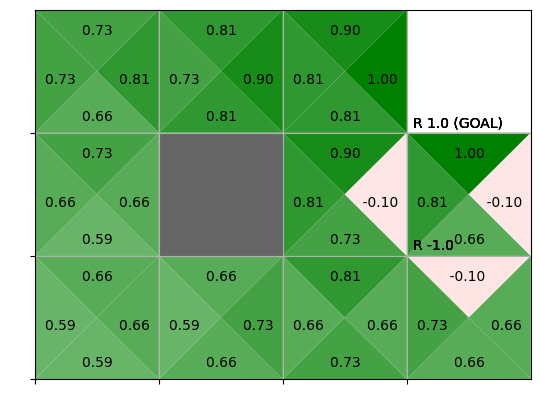

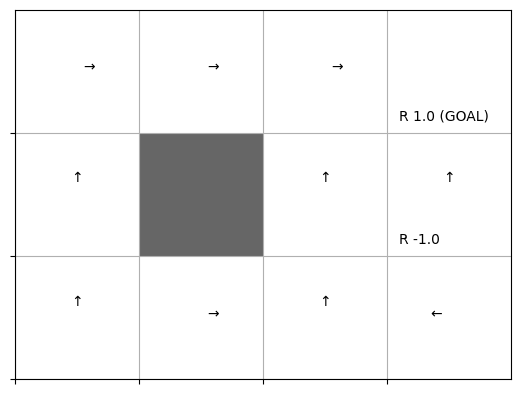

In [16]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4

        random_actions = {0: 0.25, 1: 0.25, 2: 0.25, 3: 0.25}
        self.pi = defaultdict(lambda: random_actions)
        self.b = defaultdict(lambda: random_actions)
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        action_probs = self.b[state]
        actions = list(action_probs.keys())
        probs = list(action_probs.values())
        return np.random.choice(actions, p=probs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha

        self.pi[state] = greedy_probs(self.Q, state, epsilon=0)
        self.b[state] = greedy_probs(self.Q, state, self.epsilon)


env = GridWorld()
agent = QLearningAgent()

episodes = 10000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

**5. Q-Learning (버전 2: 딕셔너리로 b와 pi를 유지하지 않고, get_action에서 즉석으로 엡실론-탐욕을 계산하여 메모리와 연산을 최적화)**

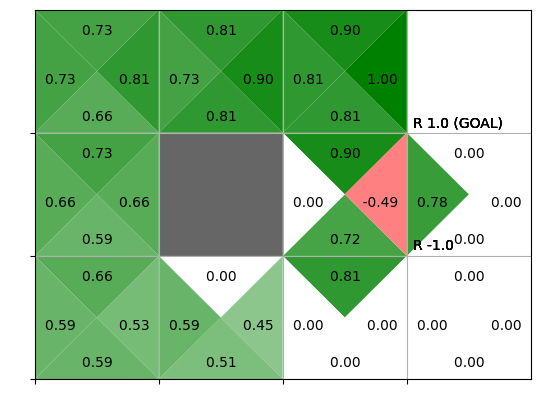

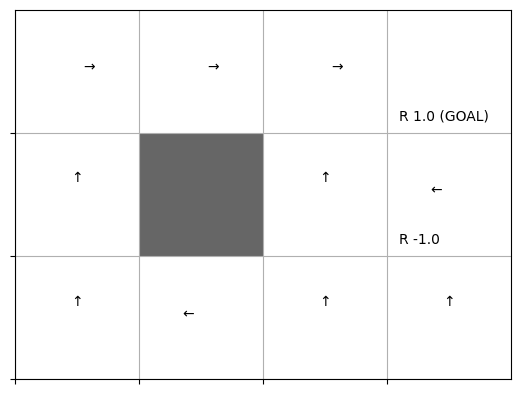

In [17]:
class QLearningAgent:
    def __init__(self):
        self.gamma = 0.9
        self.alpha = 0.8
        self.epsilon = 0.1
        self.action_size = 4
        self.Q = defaultdict(lambda: 0)

    def get_action(self, state):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.action_size)
        else:
            qs = [self.Q[state, a] for a in range(self.action_size)]
            return np.argmax(qs)

    def update(self, state, action, reward, next_state, done):
        if done:
            next_q_max = 0
        else:
            next_qs = [self.Q[next_state, a] for a in range(self.action_size)]
            next_q_max = max(next_qs)

        target = reward + self.gamma * next_q_max
        self.Q[state, action] += (target - self.Q[state, action]) * self.alpha


env = GridWorld()
agent = QLearningAgent()

episodes = 1000
for episode in range(episodes):
    state = env.reset()

    while True:
        action = agent.get_action(state)
        next_state, reward, done = env.step(action)

        agent.update(state, action, reward, next_state, done)
        if done:
            break
        state = next_state

env.render_q(agent.Q)

# **결과 분석 및 서술형 문제**

■ 과제 수행 방법:

DP, MC, TD의 모든 에이전트 코드를 순서대로 실행해보십시오. 각 학습이 완료된 후 출력되는 그리드월드 상의 가치(Value) 또는 Q-값(상태-행동 가치)과 에이전트의 정책 방향 화살표를 주의 깊게 관찰한 뒤, 아래의 질문에 대해 서술형으로 답안을 작성하여 제출 바랍니다.

**[문제 1]**

동적 계획법(DP)의 value_iter 코드와 시간차 학습(TD)의 QLearningAgent 코드를 비교해 보십시오.

DP는 에피소드를 진행하며 환경과 상호작용할 필요 없이 가치를 계산할 수 있었습니다. 그 이유(DP의 전제 조건)가 무엇인지 설명하고, 자율주행이나 주식 거래와 같은 현실 세계의 복잡한 문제에서 DP 대신 MC나 TD와 같은 모델 프리(Model-free) 알고리즘을 사용해야만 하는 이유를 서술하시오.

답안:

동적 계획법(DP)은 에피소드를 실제로 진행하며 환경과 상호작용하지 않아도 가치를 계산할 수 있다. 그 이유는 환경의 모델을 이미 알고 있다는 전제가 있기 때문이다. 예를 들어 value_iter에서는 모든 상태에 대해 가능한 행동을 순회하면서, 각 행동이 만들어낼 다음 상태와 보상을 바탕으로 기대 가치를 계산한다. 이 과정은 실제 에이전트가 환경에서 움직여 보지 않아도 가능하다. 따라서 DP의 핵심 전제 조건은 완전한 환경 모델의 존재라고 볼 수 있다.

하지만 자율주행이나 주식 거래와 같은 현실 세계 문제에서는 이러한 전제가 성립하기 어렵다.

현실 환경은 매우 복잡하고 불확실하여 상태 전이 확률과 보상 구조를 정확히 알기 어렵다. 자율주행에서는 도로 상황, 보행자 행동, 날씨, 다른 차량의 움직임 등이 계속 변하며, 주식 거래에서는 시장 참여자들의 행동과 외부 경제 요인 때문에 다음 상태를 명확히 모델링하기 어렵다.

또한 상태 공간과 행동 공간이 매우 커서 설령 모델을 안다고 해도 DP 방식으로 모든 상태를 순회하며 계산하는 것이 비현실적이다.

마지막으로, 현실에서는 모델이 고정되어 있지 않고 계속 변할 수 있으므로, 미리 알고 있는 완전한 모델을 가정하기 어렵다.

이 때문에 현실 문제에서는 DP 대신 모델 프리(Model-free) 알고리즘인 MC나 TD를 사용한다. MC와 TD는 환경의 전이 확률이나 보상 함수를 명시적으로 알지 못해도, 실제 경험 데이터를 통해 가치를 학습할 수 있다. MC는 에피소드가 끝난 뒤 실제 반환값(return)을 이용해 학습하고, TD는 한 스텝씩 진행하면서 현재 관측한 보상과 다음 상태의 추정값을 이용해 즉시 학습한다. 따라서 모델을 모르거나 모델링이 어려운 현실 세계에서는 DP보다 MC나 TD가 훨씬 실용적이다.

**[문제 2]**

몬테카를로 제어(McAgent)와 시간차 제어(SarsaAgent) 코드를 보면 에이전트의 가치(self.Q)를 업데이트하는 시점(메서드 호출 시점)이 다릅니다.

1. 두 알고리즘이 각각 어느 시점에 가치를 업데이트하는지 코드를 바탕으로 설명하시오.

2. 이러한 업데이트 시점의 차이로 인해 발생하는 장단점(학습 속도, 편향과 분산 등)을 비교하여 서술하시오.

답안:

1.

먼저 몬테카를로 제어의 McAgent는 에피소드가 종료된 이후에 가치를 업데이트한다. 일반적으로 코드를 보면 에피소드 동안 방문한 상태, 행동, 보상을 리스트에 저장해 두었다가, 마지막에 에피소드가 끝나면 역순으로 return을 계산하며 self.Q를 갱신한다. 즉, MC는 에피소드 종료 후 한꺼번에 반영된다.

반면 시간차 제어인 SarsaAgent는 매 스텝마다 가치를 업데이트한다. 현재 상태 state, 현재 행동 action, 받은 보상 reward, 다음 상태 next_state, 그리고 다음에 실제 선택한 행동 next_action이 주어지면 즉시 Q값을 갱신한다. 즉, SARSA는 에피소드가 끝날 때까지 기다리지 않고, 한 번 행동할 때마다 바로 학습한다.

2.

이러한 업데이트 시점 차이로 인해 장단점이 발생한다.

MC의 장점은 실제 return을 바탕으로 학습한다는 점이다. 에피소드가 끝난 뒤 얻은 실제 누적보상을 사용하므로, 부트스트래핑으로 인한 추정 오차가 덜 섞인다. 따라서 이론적으로는 편향이 상대적으로 작다고 볼 수 있다. 그러나 단점도 크다. 에피소드가 끝날 때까지 기다려야 하므로 학습이 느리고, 긴 에피소드에서는 업데이트가 매우 늦어진다. 또한 하나의 에피소드 결과가 우연에 크게 좌우될 수 있어 분산이 큰 편이다.

반대로 SARSA의 장점은 매 스텝 즉시 업데이트할 수 있어서 학습이 빠르다는 점이다. 에피소드가 길어도 중간중간 지속적으로 학습할 수 있으므로 온라인 학습에 적합하다. 그러나 다음 상태의 추정값을 이용하는 부트스트래핑을 사용하기 때문에, 아직 정확하지 않은 추정값이 다시 타겟 계산에 들어가며 편향이 생길 수 있다. 대신 실제 return 전체를 기다리지 않으므로 MC보다 분산은 상대적으로 작아지는 경향이 있다.

정리하면, MC는 느리지만 편향이 작고 분산이 큰 방법, SARSA는 빠르지만 일부 편향을 감수하고 분산을 줄이는 방법이라고 비교할 수 있다.



**[문제 3]**

TD 학습 파트에서 SarsaAgent(활성 정책)와 QLearningAgent(비활성 정책)의 update 메서드 내부를 살펴보면, TD 타겟(Target)을 계산하는 방식에 핵심적인 차이가 있습니다.

1. SARSA는 타겟 계산을 위해 다음 상태의 어떤 값을 참조하며, Q-Learning은 어떤 값을 참조하는지 코드의 구체적인 변수명이나 로직을 들어 설명하시오.

2. 이 차이로 인해 그리드월드의 '함정' 근처에서 두 에이전트가 학습하는 최적 경로(안전 추구 vs. 최단 경로 추구)가 어떻게 달라질 수 있는지 추론하여 서술하시오.

답안:

1.

SARSA와 Q-Learning의 핵심 차이는 TD 타겟을 계산할 때 다음 상태에서 어떤 값을 참조하느냐에 있다.

먼저 SarsaAgent는 활성 정책(on-policy) 방식이므로, 다음 상태 next_state에서 실제로 현재 정책에 따라 선택한 다음 행동 next_action의 Q값을 참조한다. 코드 수준에서 보면 update(state, action, reward, next_state, next_action)처럼 next_action이 인자로 함께 들어오고, self.Q[next_state][next_action] 또는 이에 해당하는 값을 사용해 타겟을 계산하는 구조이다. 즉, SARSA는 “내가 실제로 다음에 이렇게 행동할 것이므로, 그 행동의 가치까지 포함해 현재를 업데이트하자”라는 방식이다.

반면 QLearningAgent는 비활성 정책(off-policy) 방식이므로, 다음 상태에서 실제로 선택한 행동과 무관하게 가능한 행동들 중 최대 Q값을 참조한다.코드로는 max(self.Q[next_state]) 혹은 np.argmax와 연계된 최대값 참조 로직이 들어간다. 즉, Q-Learning은 “다음 상태에서 가장 좋은 행동을 할 것이라고 가정하고 현재를 업데이트하자”라는 방식이다.

2.

이 차이는 그리드월드의 함정 근처에서 학습되는 경로에 직접적인 영향을 준다.

SARSA는 현재 정책 자체가 탐험을 포함하고 있기 때문에, 다음 상태에서 실제로는 실수하거나 탐험 행동을 하다가 함정 쪽으로 갈 가능성도 간접적으로 반영한다. 따라서 함정 가까이를 지나가는 최단 경로가 있더라도, 그 경로는 탐험 중 작은 실수만으로 큰 손실을 볼 수 있으므로 상대적으로 덜 선호하게 된다. 결과적으로 SARSA는 더 안전한 우회 경로를 학습하는 경향이 있다.

반면 Q-Learning은 다음 상태에서 항상 최적 행동만 할 것처럼 최대값을 사용하므로, 탐험 중 발생할 수 있는 위험을 타겟 계산에 직접 반영하지 않는다. 따라서 함정 옆을 스쳐 지나가는 길이 실제 최단 경로라면, 위험을 덜 고려한 채 더 공격적이고 짧은 경로를 학습할 가능성이 크다. 즉, SARSA는 안전 추구 성향이 강하고, Q-Learning은 최단 경로 추구 성향이 강하다고 볼 수 있다.

**[문제 4]**

McOffPolicyAgent 및 SarsaOffPolicyAgent 코드를 보면, 직접 행동을 결정하는 정책(self.b)과 궁극적으로 최적화하려는 목표 정책(self.pi) 두 가지를 분리하여 운영합니다.

1. 왜 하나의 정책으로만 학습하지 않고 굳이 두 개의 정책을 분리해서 학습하는지 '탐험(Exploration)과 활용(Exploitation)의 딜레마' 관점에서 설명하시오.

2. 비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율인 rho($\rho$)를 곱해줍니다. 이 비율을 곱해주는 수학적/논리적 이유가 무엇인지 서술하시오.

답안:

1.

비활성 정책(off-policy) 알고리즘에서는 행동 정책 self.b와 목표 정책 self.pi를 분리하여 사용한다. 이렇게 두 개의 정책을 따로 두는 이유는 탐험과 활용의 딜레마를 동시에 해결하기 위해서이다.

만약 하나의 정책만 사용한다면, 아직 충분히 시도해 보지 않은 다른 행동들의 가치를 알 수 없어서 더 좋은 정책을 발견하지 못할 수 있다. 반대로 탐험만 지나치게 하면 다양한 행동은 시도할 수 있지만, 이미 배운 좋은 행동을 충분히 활용하지 못한다.

이때 self.b는 실제로 데이터를 수집할 때 사용하는 정책으로, 보통 ε-greedy처럼 어느 정도 무작위성을 포함하여 탐험을 수행한다. 반면 self.pi는 궁극적으로 최적화하고 싶은 정책으로, 보통 greedy 정책에 가깝다. 즉, 실제 행동은 self.b로 하되, 학습의 방향은 self.pi를 향하게 만드는 구조이다. 이것이 off-policy의 핵심이다.

2.

비활성 정책 코드에서 가치를 업데이트할 때 중요도 샘플링 비율 rho(ρ)를 곱하는 이유는, 행동 정책 b로 수집한 데이터를 목표 정책 pi를 따랐을 때의 데이터처럼 보정하기 위해서이다. 우리가 실제로 얻은 경험은 목표 정책이 아니라 행동 정책으로부터 나온 것이므로, 이를 그대로 사용하면 목표 정책의 가치에 대한 올바른 추정이 되지 않는다. 따라서 각 경로 또는 각 행동 선택이 목표 정책에서는 얼마나 가능성이 높고, 행동 정책에서는 얼마나 가능성이 높았는지를 비율로 계산하여 보정해야 한다.

수학적으로는 어떤 trajectory나 action sequence가 목표 정책 하에서 발생할 확률을 행동 정책 하에서 발생할 확률로 나눈 값이 중요도 샘플링 비율이다. 이 비율을 곱하면 행동 정책으로부터 얻은 표본의 기대값을 목표 정책의 기대값으로 변환할 수 있다. 즉, 행동 정책에서 자주 나왔지만 목표 정책에서는 잘 나오지 않을 행동은 가중치를 낮추고, 반대로 행동 정책에서는 드물지만 목표 정책에서는 중요한 행동은 가중치를 높여서, 결국 목표 정책 기준으로 올바른 가치 추정을 하려는 것이다.

**[문제 5]**

실습에 사용된 그리드월드의 보상 체계를 변경한다고 가정해 봅시다. 현재는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상을 받습니다.

만약 에이전트가 가능한 한 빨리 목적지에 도달하도록 유도하기 위해, 매 스텝 이동할 때마다 -0.01의 페널티 보상을 주도록 환경(Environment)을 변경한다면, 학습이 완료된 후의 최적 정책(화살표 방향)과 가치 함수는 기존과 비교하여 어떤 식으로 변할지 예상하여 논리적으로 서술하시오.

답안:

기존 그리드월드에서는 도착 지점에 도달하면 +1, 함정에 빠지면 -1의 보상만 존재하므로, 중간 경로의 길이에 대한 직접적인 불이익은 없다. 따라서 에이전트는 도착만 할 수 있다면 다소 돌아가더라도 큰 차이가 없다고 학습할 수 있다. 그러나 매 스텝마다 -0.01의 페널티를 주면, 에이전트는 같은 목적지에 도달하더라도 더 적은 스텝으로 도착하는 경로를 훨씬 선호하게 된다.

최적 정책(화살표 방향)은 전반적으로 더 짧은 경로를 선택하는 방향으로 바뀔 가능성이 크다. 기존에는 안전성을 이유로 약간 우회하는 경로와 직선 경로의 차이가 크지 않았다면, 이제는 한 칸 한 칸 이동할 때마다 손해를 보기 때문에 우회 비용이 누적된다. 따라서 도착점으로 가는 더 직접적인 방향으로 화살표가 정렬될 가능성이 높다. 다만 함정에 빠질 위험이 너무 큰 구간에서는 여전히 함정을 피하려는 경향이 남아 있을 수 있다. 즉, 정책은 “무조건 안전한 우회”보다 “가능한 한 빠르되 지나치게 위험하지 않은 경로” 쪽으로 이동할 것이다.

가치 함수 측면에서는 대부분의 상태 가치가 기존보다 전반적으로 더 낮아질 가능성이 크다. 왜냐하면 도착하기 전까지 이동할 때마다 계속 -0.01을 누적해서 받기 때문이다. 도착점에서 멀리 떨어진 상태일수록 앞으로 더 많은 스텝 페널티를 감수해야 하므로 가치가 더 낮아진다. 반대로 도착점에 가까운 상태는 남은 페널티가 적으므로 상대적으로 더 높은 가치를 가진다. 따라서 가치 함수의 분포는 기존보다 도착점과의 거리 차이를 더 민감하게 반영하게 된다.

정리하면, 매 스텝 페널티를 도입하면 학습 완료 후의 최적 정책은 더 빠른 도착을 지향하는 방향으로 변하고, 가치 함수는 도착점까지 남은 거리와 경로 길이 차이를 더 뚜렷하게 반영하는 형태로 바뀔 것이다. 전체적으로 시간 지연에 대한 비용이 가치에 포함되는 구조가 된다.

수고하셨습니다.